In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from ase.db import connect

from asmcmc.measurements import TrajectoryAnalyzer, RadialDistributionFunction, OrientationalCorrelationFunction, NematicOrderParameter, HeatCapacity, EffectiveSampleSize

sns.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})

In [2]:
temps = [40, 70, 85, 100, 115, 130, 145, 160, 175]
pressures = [1e-5, 1e-4, 3e-4]
press_names = ["1e-05", "0.0001", "0.0003"]

In [3]:
# Collect results for only 1e-5 pressure

seeds = {
    40: 12345,
    70: 12346,
    85: 12347,
    100: 12348,
    115: 12349,
    130: 12350,
    145: 12351,
    160: 12352,
    175: 12353
}

db_paths = [f"../results/npt_scan/T{temp}_P1e-05/{seeds[temp]}/simulation.db" for temp in temps]
trajs = {}
for temp, path in zip(temps, db_paths):
    frames = []
    with connect(path) as db:
        for row in db.select():
            frames.append(row.toatoms())
    trajs[temp] = frames

# Maximum radius valid for the RDF / orientational correlation.
#
# The minimum-image convention only resolves separations out to half the
# SHORTEST box edge. These NPT boxes are non-cubic (the columnar start leaves
# the column axis ~33-38 A vs ~26-31 A for the other two), so we must use the
# shortest edge -- frame.cell.lengths().min() -- not a single lattice vector.
# Take the global minimum over all frames AND all temperatures so every curve
# shares the same valid range (the box shrinks as T drops, so the cold end sets
# the limit).
min_lens = []
for temp in temps:
    cell_lens = [frame.cell.lengths().min() for frame in trajs[temp]]
    min_lens.append(np.min(cell_lens))

r_max = np.min(min_lens) / 2
print(f"r_max: {r_max}")

r_max: 13.212124269926463


In [4]:
# Bin width ~0.05 A (fine enough to resolve the split crystalline peaks, coarse
# enough to stay smooth over 5000 frames). Derive the count from r_max so the
# physical resolution is fixed regardless of the cutoff.
num_bins = int(round(r_max / 0.05))

measurements = {}

for temp, path in zip(temps, db_paths):
    analyzer = TrajectoryAnalyzer(path)

    analyzer.add_measurement("rdf", RadialDistributionFunction(r_max=r_max, num_bins=num_bins))
    analyzer.add_measurement("ocf", OrientationalCorrelationFunction(r_max=r_max, num_bins=num_bins))
    analyzer.add_measurement("nop", NematicOrderParameter())
    analyzer.add_measurement("c_p", HeatCapacity(temp, 125))

    measurements[temp] = analyzer.run_analysis()

Analyzing Trajectory:   0%|          | 0/5000 [00:00<?, ?it/s]

Analyzing Trajectory:   0%|          | 0/5000 [00:00<?, ?it/s]

Analyzing Trajectory:   0%|          | 0/5000 [00:00<?, ?it/s]

Analyzing Trajectory:   0%|          | 0/5000 [00:00<?, ?it/s]

Analyzing Trajectory:   0%|          | 0/5000 [00:00<?, ?it/s]

Analyzing Trajectory:   0%|          | 0/5000 [00:00<?, ?it/s]

Analyzing Trajectory:   0%|          | 0/5000 [00:00<?, ?it/s]

Analyzing Trajectory:   0%|          | 0/5000 [00:00<?, ?it/s]

Analyzing Trajectory:   0%|          | 0/5000 [00:00<?, ?it/s]

In [5]:
# --- Ridgeline (joyplot) helper -------------------------------------------------
# Stacks a per-temperature curve (RDF g(r) or orientational correlation s2(r))
# into overlapping rows -- coldest at the bottom, hottest at the top -- so the
# structural evolution with temperature reads top-to-bottom. Colored by a
# temperature colormap (blue = cold, red = hot).

def ridge_dataframe(measurements, meas_key, val_key):
    """Long-form (temp, r, value) frame from the per-temp measurement dicts."""
    rows = []
    for temp in temps:
        m = measurements[temp][meas_key]
        for r, v in zip(m["r"], m[val_key]):
            rows.append({"temp": temp, "r": r, "value": v})
    return pd.DataFrame(rows)


def ridgeline(measurements, meas_key, val_key, xlabel, title,
              overlap=0.6, ref_line=None, savepath=None):
    """Seaborn FacetGrid ridgeline of a per-temperature curve vs r."""
    df = ridge_dataframe(measurements, meas_key, val_key)

    # Map each temperature to a color on a cold->hot colormap.
    norm = plt.Normalize(min(temps), max(temps))
    cmap = plt.cm.coolwarm
    pal = {t: cmap(norm(t)) for t in temps}

    # Hottest temperature on top: FacetGrid stacks row_order top-to-bottom.
    g = sns.FacetGrid(df, row="temp", hue="temp", row_order=temps[::-1],
                      palette=pal, aspect=12, height=0.7)
    g.map(plt.fill_between, "r", "value", alpha=0.8, lw=0)
    g.map(plt.plot, "r", "value", color="w", lw=1.0)

    if ref_line is not None:
        g.refline(y=ref_line, linewidth=0.8, linestyle="--", color="0.4")

    def annotate(x, color, label):
        plt.gca().text(0.0, 0.1, f"{int(float(label))} K", color=color,
                       fontweight="bold", ha="left", va="center",
                       transform=plt.gca().transAxes)
    g.map(annotate, "r")

    g.figure.subplots_adjust(hspace=-overlap)
    g.set_titles("")
    g.set(yticks=[], ylabel="")
    g.despine(left=True)
    for ax in g.axes.flat:
        ax.set_xlabel("")
    g.axes.flat[-1].set_xlabel(xlabel)
    g.figure.suptitle(title, y=0.98)

    if savepath:
        g.figure.savefig(savepath, dpi=150, bbox_inches="tight")
        print(f"saved {savepath}")
    return g


saved ../results/npt_scan/rdf_ridgeline_P1e-05.png


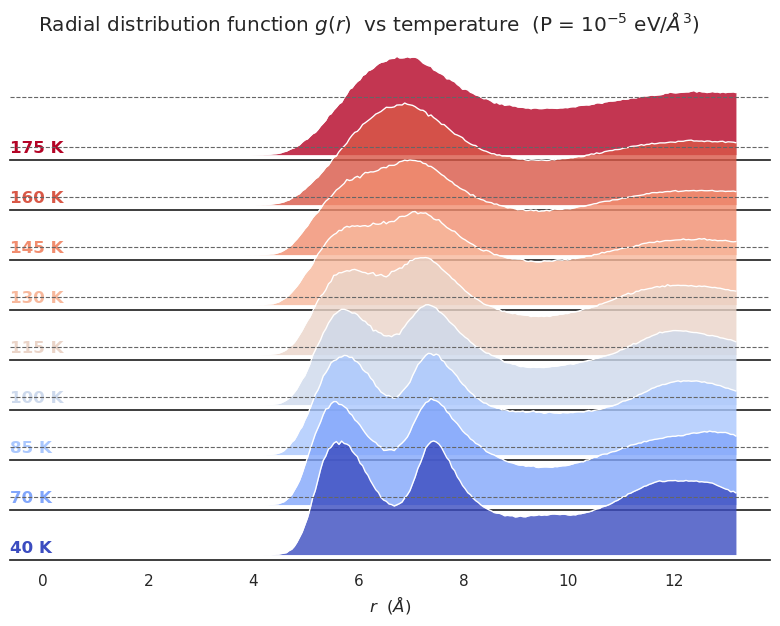

In [6]:
# Radial distribution function g(r), stacked by temperature (P = 1e-5 eV/A^3).
# Sharp split peaks at low T (crystal) broaden and merge toward a liquid-like
# g(r) as temperature rises. g(r) -> 1 at large r is marked.
ridgeline(
    measurements, "rdf", "g_r",
    xlabel=r"$r$  ($\AA$)",
    title=r"Radial distribution function $g(r)$  vs temperature  (P = $10^{-5}$ eV/$\AA^3$)",
    ref_line=1.0,
    savepath="../results/npt_scan/rdf_ridgeline_P1e-05.png",
)
plt.show()


saved ../results/npt_scan/ocf_ridgeline_P1e-05.png


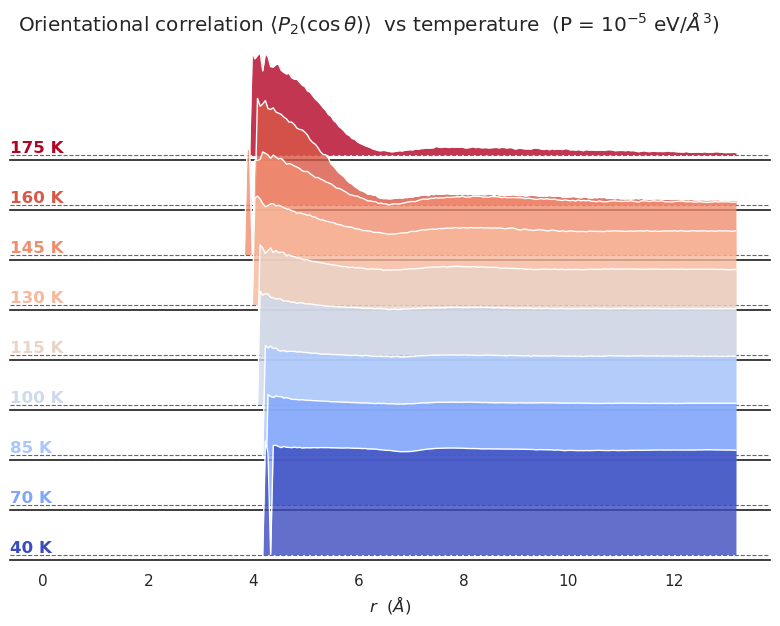

In [7]:
# Orientational correlation s2(r) = <P2(cos theta)>, stacked by temperature.
# Long-range orientational order (s2 staying high out to large r) at low T
# collapses toward 0 (random relative orientation) as the system disorders.
ridgeline(
    measurements, "ocf", "s2_r",
    xlabel=r"$r$  ($\AA$)",
    title=r"Orientational correlation $\langle P_2(\cos\theta)\rangle$  vs temperature  (P = $10^{-5}$ eV/$\AA^3$)",
    ref_line=0.0,
    savepath="../results/npt_scan/ocf_ridgeline_P1e-05.png",
)
plt.show()
